In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, resample

In [2]:
# Load PTB-XL record
record_path = "data/ptbxl_input/records500/00000/00001_hr"

record = wfdb.rdrecord(record_path)

signal = record.p_signal
fs = record.fs

print("Sampling frequency:", fs)
print("Number of leads:", signal.shape[1])
print("Signal length:", signal.shape[0])
print("Lead names:", record.sig_name)

Sampling frequency: 500
Number of leads: 12
Signal length: 5000
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


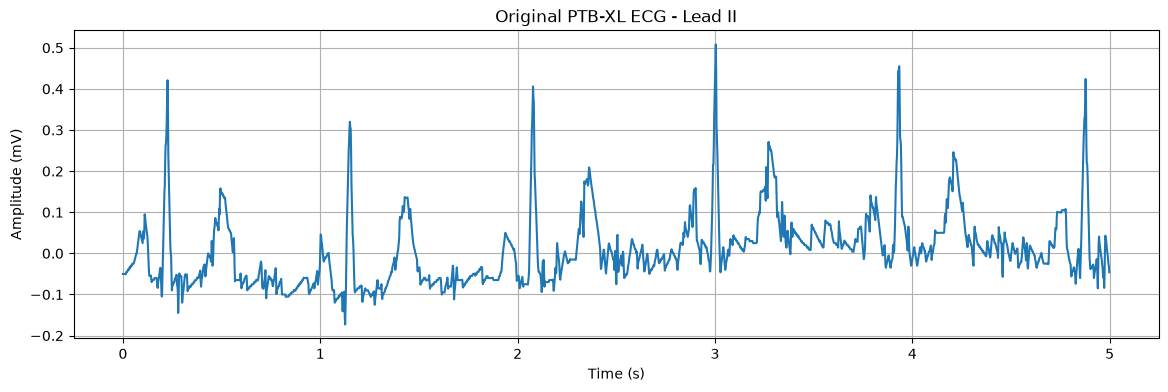

In [3]:
# Plot Lead II
lead = signal[:, 1]
time = np.arange(len(lead)) / fs

plt.figure(figsize=(14, 4))
plt.plot(time[:2500], lead[:2500])
plt.title("Original PTB-XL ECG - Lead II")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

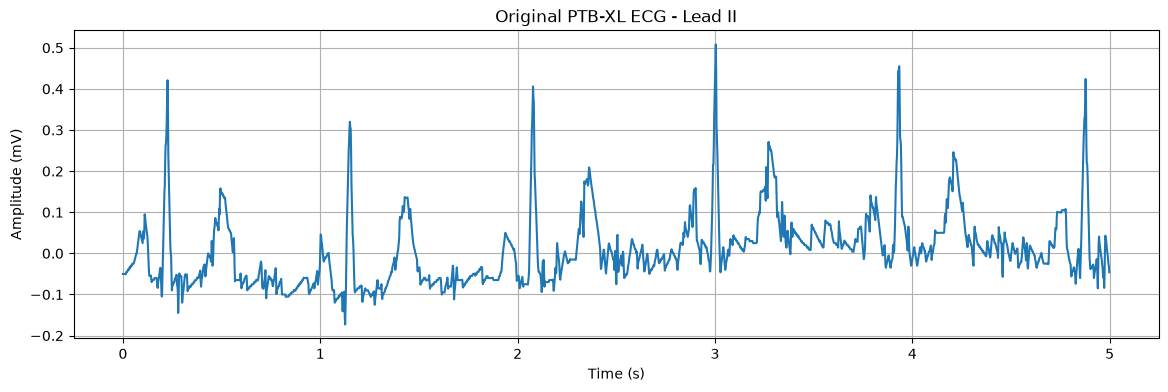

In [4]:
# Plot Lead II
lead = signal[:, 1]
time = np.arange(len(lead)) / fs

plt.figure(figsize=(14, 4))
plt.plot(time[:2500], lead[:2500])
plt.title("Original PTB-XL ECG - Lead II")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

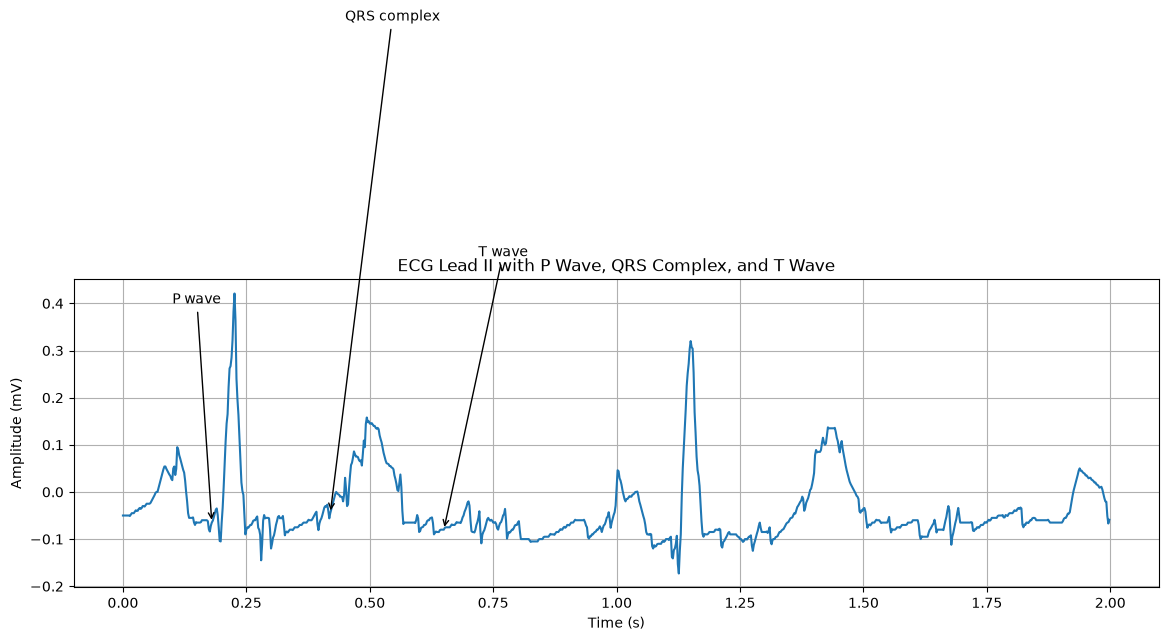

In [5]:
# Label P wave, QRS complex, and T wave
plt.figure(figsize=(14, 4))
plt.plot(time[:1000], lead[:1000])

plt.annotate("P wave", xy=(0.18, lead[int(0.18 * fs)]), xytext=(0.10, 0.4),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("QRS complex", xy=(0.42, lead[int(0.42 * fs)]), xytext=(0.45, 1.0),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("T wave", xy=(0.65, lead[int(0.65 * fs)]), xytext=(0.72, 0.5),
             arrowprops=dict(arrowstyle="->"))

plt.title("ECG Lead II with P Wave, QRS Complex, and T Wave")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

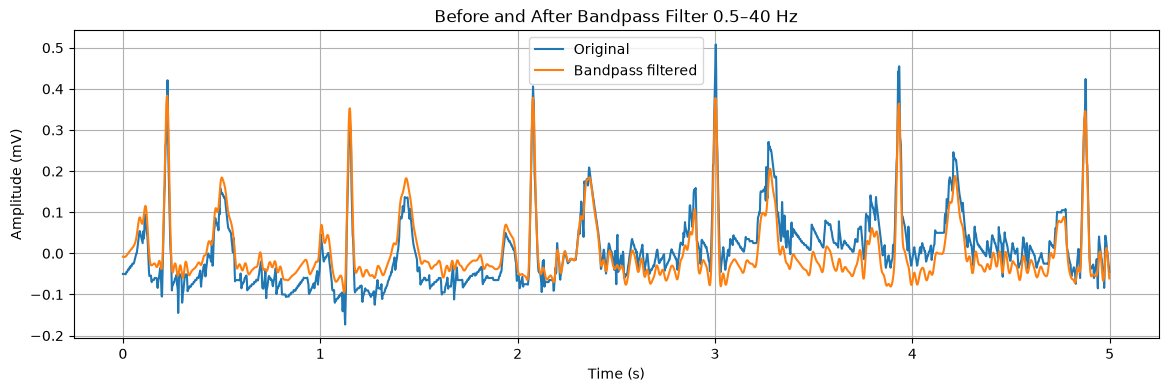

In [6]:
# Bandpass filter: 0.5–40 Hz
def bandpass_filter(x, fs, lowcut=0.5, highcut=40, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, x)

bandpassed = bandpass_filter(lead, fs)

plt.figure(figsize=(14, 4))
plt.plot(time[:2500], lead[:2500], label="Original")
plt.plot(time[:2500], bandpassed[:2500], label="Bandpass filtered")
plt.title("Before and After Bandpass Filter 0.5–40 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)
plt.show()

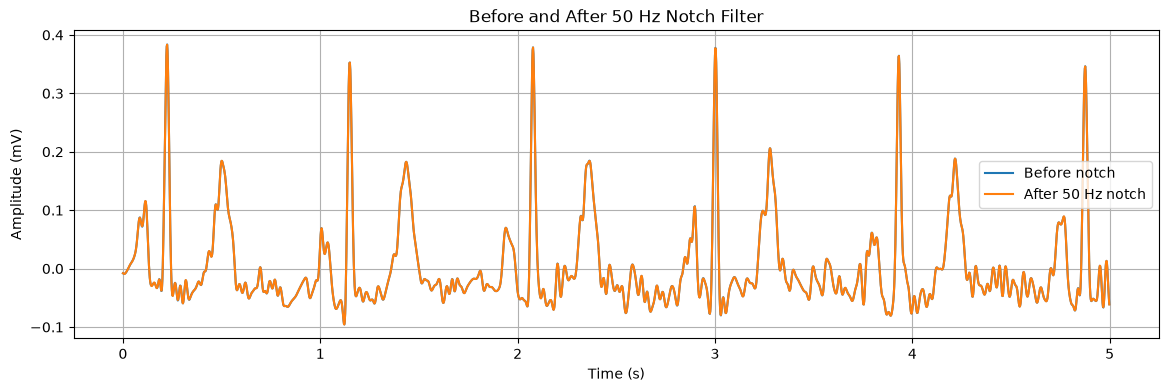

In [7]:
# Notch filter: 50 Hz
def notch_filter(x, fs, freq=50, quality=30):
    b, a = iirnotch(freq, quality, fs)
    return filtfilt(b, a, x)

notched = notch_filter(bandpassed, fs)

plt.figure(figsize=(14, 4))
plt.plot(time[:2500], bandpassed[:2500], label="Before notch")
plt.plot(time[:2500], notched[:2500], label="After 50 Hz notch")
plt.title("Before and After 50 Hz Notch Filter")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Compare SaMi-Trop and PTB-XL
# Change sami_path to one of your SaMi-Trop WFDB records

sami_path = "data/samitrop_wfdb/RECORD_NAME_HERE"
ptb_path = "data/ptbxl_input/records500/00000/00001_hr"

try:
    sami = wfdb.rdrecord(sami_path)
    ptb = wfdb.rdrecord(ptb_path)

    sami_lead = sami.p_signal[:, 1]
    ptb_lead = ptb.p_signal[:, 1]

    sami_fs = sami.fs
    ptb_fs = ptb.fs

    target_fs = 400

    sami_resampled = resample(sami_lead, int(len(sami_lead) * target_fs / sami_fs))
    ptb_resampled = resample(ptb_lead, int(len(ptb_lead) * target_fs / ptb_fs))

    t_sami = np.arange(len(sami_resampled)) / target_fs
    t_ptb = np.arange(len(ptb_resampled)) / target_fs

    plt.figure(figsize=(14, 4))
    plt.plot(t_sami[:2000], sami_resampled[:2000], label="SaMi-Trop Chagas-positive")
    plt.plot(t_ptb[:2000], ptb_resampled[:2000], label="PTB-XL Chagas-negative")
    plt.title("Chagas-positive vs Chagas-negative ECG Comparison")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print("Update sami_path to a valid SaMi-Trop WFDB record before running this cell.")
    print(e)

Update sami_path to a valid SaMi-Trop WFDB record before running this cell.
[Errno 2] No such file or directory: '/workspaces/cinc2025-practice/data/samitrop_wfdb/RECORD_NAME_HERE.hea'


In [9]:
print("SaMi-Trop WFDB folder was not found in this Codespace.")
print("PTB-XL is Chagas-negative. SaMi-Trop comparison will be added after downloading/preparing SaMi-Trop.")

SaMi-Trop WFDB folder was not found in this Codespace.
PTB-XL is Chagas-negative. SaMi-Trop comparison will be added after downloading/preparing SaMi-Trop.


In [10]:
print("""
Observation:
The Chagas-positive and Chagas-negative ECGs may show visual differences in rhythm,
QRS shape, and wave morphology. However, one visual comparison is not enough to diagnose
Chagas disease. A reliable conclusion would require many records and clinical labels.
""")


Observation:
The Chagas-positive and Chagas-negative ECGs may show visual differences in rhythm,
QRS shape, and wave morphology. However, one visual comparison is not enough to diagnose
Chagas disease. A reliable conclusion would require many records and clinical labels.

